In [16]:
!pip install kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "retail_sales_dataset.csv"  

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mohammadtalib786/retail-sales-dataset",
    file_path
)

C:\Users\ayush\AppData\Local\Temp\ipykernel_29844\2907967907.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [2]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

df.columns

In [7]:
df.duplicated().sum()

np.int64(0)

### Key Performance Indicators

In [8]:
#Total Revenue
print("Total revenue generated : ", df['Total Amount'].sum())
#Total Transactions
print("Total Transactions : ", df['Transaction ID'].nunique())
#Total Costumers
print("Total Costumers : ", df['Customer ID'].nunique())
#Total Quantity 
print("Total Quantity : ", df['Quantity'].sum())

Total revenue generated :  456000
Total Transactions :  1000
Total Costumers :  1000
Total Quantity :  2514


In [9]:
print("Average Order value", df['Total Amount'].sum() / df['Transaction ID'].nunique())

Average Order value 456.0


## Prepare Data

In [17]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)

cat = df.groupby('Product Category')['Total Amount'].sum().reset_index()
month = df.groupby('Month')['Total Amount'].sum().reset_index()
gender = df.groupby('Gender')['Total Amount'].sum().reset_index()
age = df.groupby('Age')['Total Amount'].sum().reset_index()

## Dashboard Layout

In [27]:
fig = make_subplots(rows=2, cols=2,specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "domain"}]
    ],
    subplot_titles=(
        "Revenue by Product Category",
        "Monthly Sales Trend",
        "Age vs Spending",
        "Sales Distribution by Gender"
    )
)

### Product Category

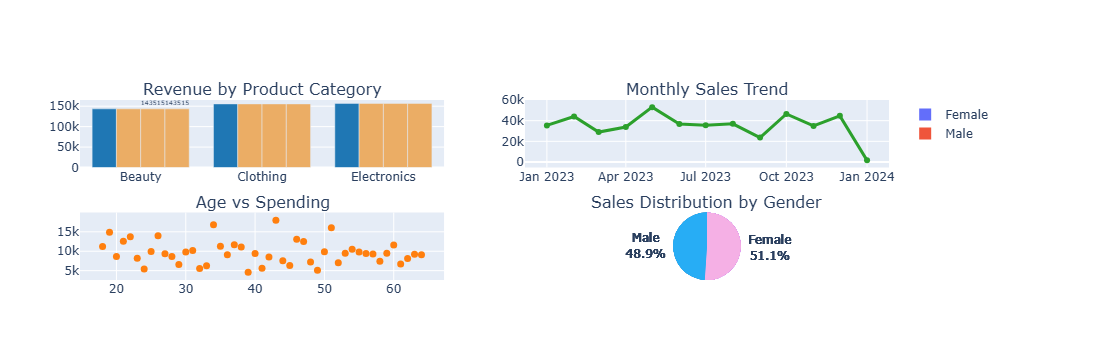

In [42]:
fig.add_trace(go.Bar( x = cat['Product Category'], y = cat['Total Amount'], marker = dict(color = '#EBAD65') , text=cat['Total Amount'],
    textposition='outside'), row = 1, col = 1)
fig.update_traces(showlegend=False, selector=dict(type='bar'))
fig.update_traces(showlegend=False, selector=dict(type='scatter'))

### Monthly Trend

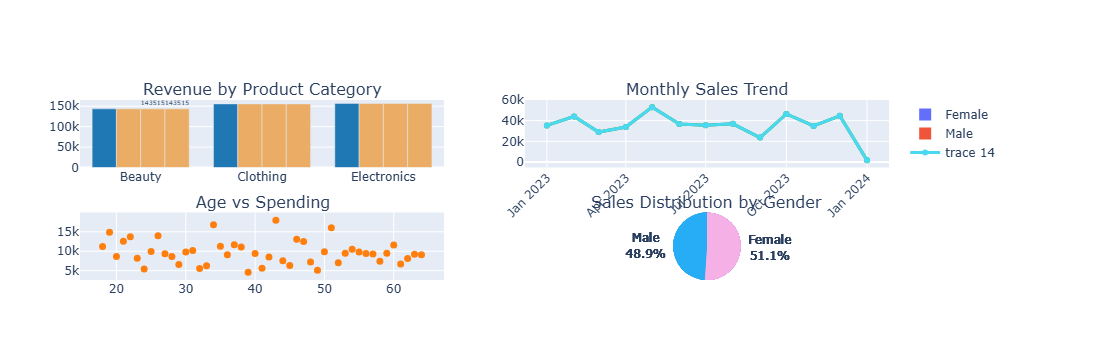

In [43]:
fig.add_trace(go.Scatter( x = month['Month'], y = month['Total Amount'], mode='lines+markers',
        line=dict(color='#4BD9F2', width=3),
        marker=dict(size=6)), row = 1, col = 2)
fig.update_xaxes(tickangle=-45, row=1, col=2)

### Age Analysis

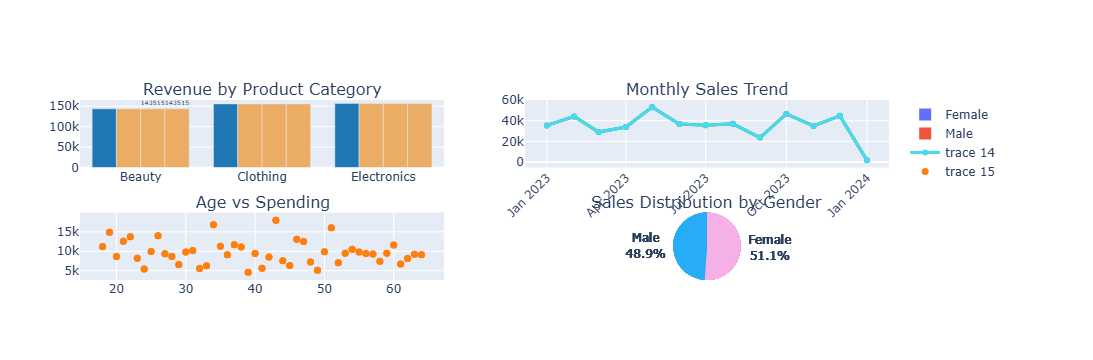

In [44]:
fig.add_trace(go.Scatter(x=age['Age'], y=age['Total Amount'], mode = 'markers',marker = dict(color='#ff7f0e', size=7)),
    row=2, col=1
)

### Gender Analysis

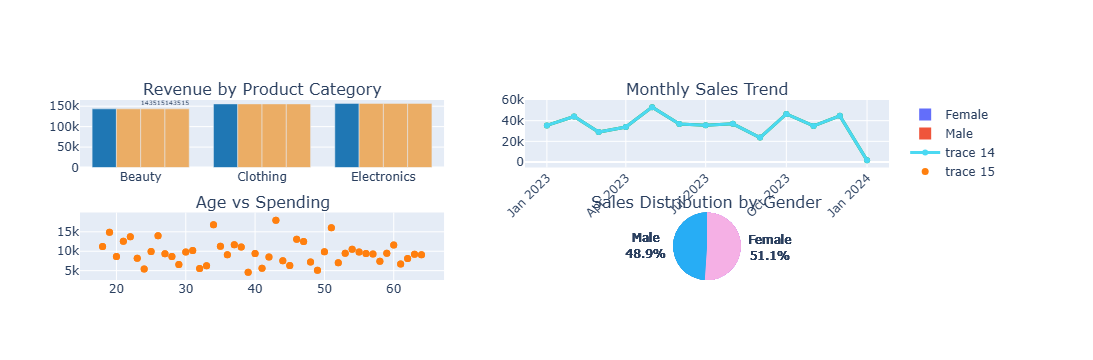

In [45]:
fig.add_trace(
    go.Pie(labels=gender['Gender'],values=gender['Total Amount'], marker_colors=['#F5B0E5', '#27ADF5'],
        textinfo='percent+label'),
    row=2, col=2)


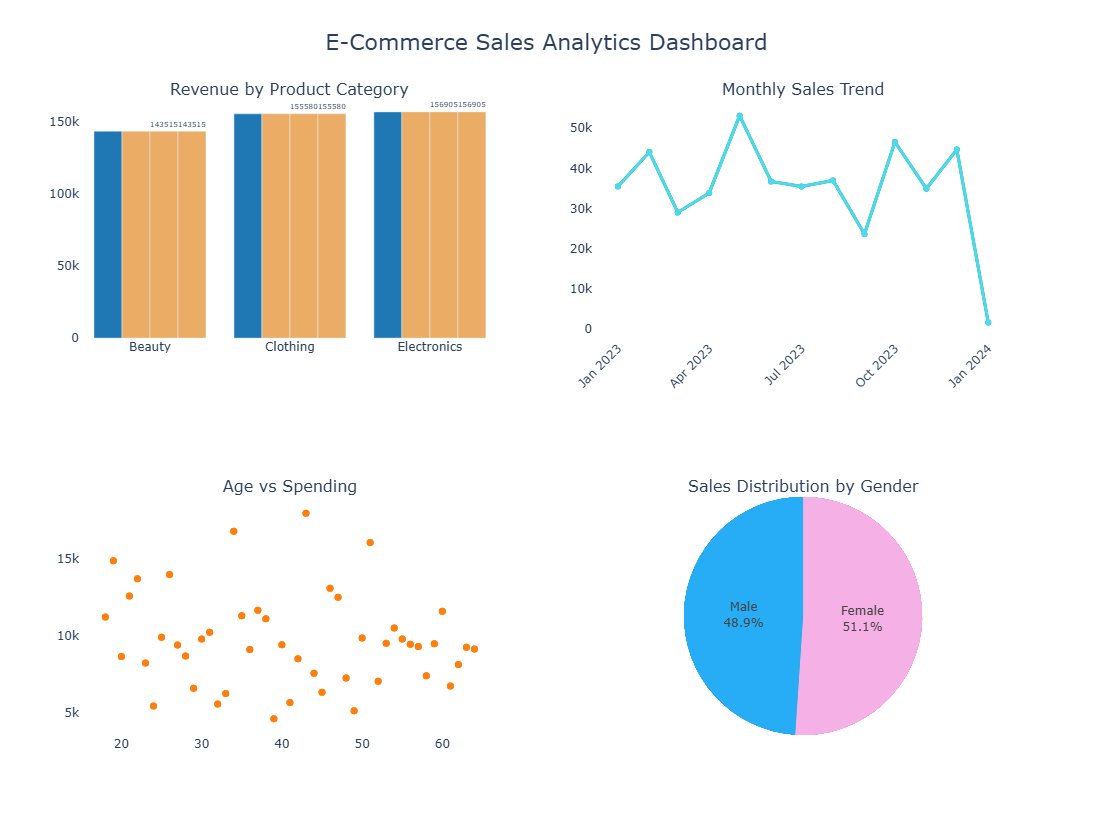

In [47]:
fig.update_layout(
    title={
        'text': "E-Commerce Sales Analytics Dashboard",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=22)
    },
    height=800,
    width=1100,
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white'
)

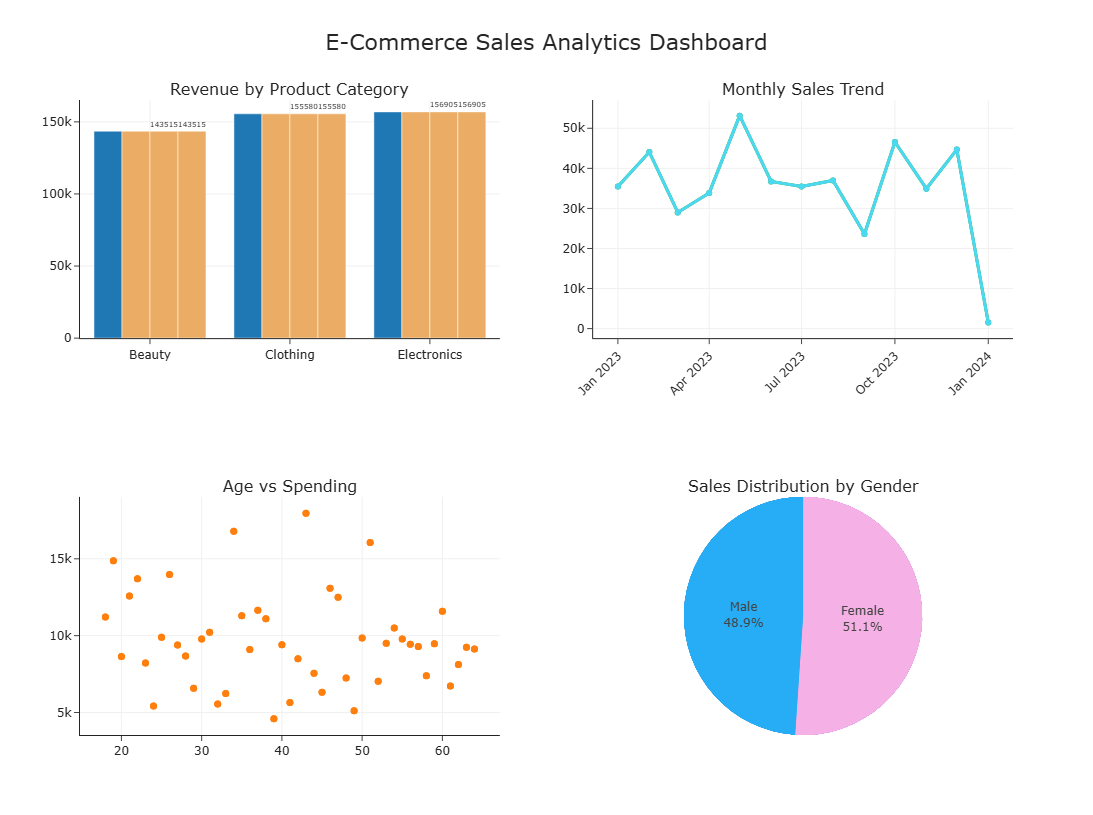

In [51]:
fig.update_layout(template="simple_white", paper_bgcolor="white", plot_bgcolor="white", title_x=0.5)

fig.update_xaxes(showgrid=True, gridcolor="#F0F0F0", showline=True)

fig.update_yaxes( showgrid=True, gridcolor="#F0F0F0", showline=True)